In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import math

## Import the dataset and ther player stats 

stats = pd.read_csv('Seasons_Stats.csv')
players = pd.read_csv('Players.csv')

stats = pd.merge(stats,players, left_on = 'Player', right_on = 'Player')

#These are currently counting stats - we want them to be on a per game basis so they can be adjusted for guys who didn't play as many games
per_game_stats = ['PTS', 'AST', 'TRB', 'STL', 'BLK', 'FGA', 'FG', 'FTA', 'FT', '3PA', '3P', '2P', '2PA','ORB','DRB','TOV','PF','MP']

#Only use the modern nba and cut out the 2017 season so we can use it for test
stats_test = stats[stats['Year'] == 2017]
stats = stats[stats['Year'] >= 2006]

#Make sure everybody in the data has played enough games to the point where they aren't a major outlier for one great game out of about 3 played.
stats_test = stats_test[stats_test['G'] > 15]
stats = stats[stats['G'] > 15]

stats = stats[stats['MP'] > 10]
stats_test = stats_test[stats_test['MP'] > 10]

# Convert the counting stats to per game stats
for stat in per_game_stats:
    stats[stat] = stats[stat] / stats['G']

for stat in per_game_stats:
    stats_test[stat] = stats_test[stat] / stats_test['G']

stats = stats[stats['Tm'] != 'TOT']

pd.set_option('display.max_columns', None)

stats.head()

,Unnamed: 0_x,Year,Player,Pos,Age,Tm,G,GS,MP,PER,TS%,3PAr,FTr,ORB%,DRB%,TRB%,AST%,STL%,BLK%,TOV%,USG%,blanl,OWS,DWS,WS,WS/48,blank2,OBPM,DBPM,BPM,VORP,FG,FGA,FG%,3P,3PA,3P%,2P,2PA,2P%,eFG%,FT,FTA,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,Unnamed: 0_y,height,weight,collage,born,birth_city,birth_state
17662,17662,2006.0,Shareef Abdur-Rahim,PF,29.0,SAC,72.0,30.0,27.236111,17.2,0.588,0.035,0.440,6.4,14.8,10.6,13.2,1.3,1.6,12.5,20.1,NaN,4.0,2.2,6.2,0.152,NaN,0.4,0.4,0.9,1.4,4.611111,8.777778,0.525,0.069444,0.305556,0.227,4.541667,8.472222,0.536,0.529,3.027778,3.861111,0.784,1.472222,3.486111,4.958333,2.069444,0.666667,0.583333,1.500000,3.152778,12.319444,2449,206.0,102.0,University of California,1976.0,Marietta,Georgia
17664,17664,2006.0,Malik Allen,PF,27.0,CHI,54.0,20.0,12.981481,11.5,0.504,0.004,0.154,7.2,15.7,11.5,4.9,1.0,1.8,11.4,19.2,NaN,0.0,1.0,1.0,0.068,NaN,-3.9,0.0,-3.9,-0.3,2.240741,4.574074,0.490,0.018519,0.018519,1.000,2.222222,4.555556,0.488,0.492,0.425926,0.703704,0.605,0.814815,1.777778,2.592593,0.370370,0.259259,0.296296,0.629630,1.703704,4.925926,2776,208.0,115.0,Villanova University,1978.0,Willingboro,New Jersey
17665,17665,2006.0,Ray Allen,SG,30.0,SEA,78.0,78.0,38.743590,22.2,0.590,0.435,0.239,2.8,10.6,6.6,17.2,1.8,0.4,10.2,27.4,NaN,9.8,-0.3,9.5,0.150,NaN,6.7,-3.1,3.6,4.2,8.730769,19.230769,0.454,3.448718,8.371795,0.412,5.282051,10.858974,0.486,0.544,4.153846,4.602564,0.903,0.910256,3.346154,4.256410,3.666667,1.346154,0.205128,2.410256,1.935897,25.064103,2450,203.0,99.0,Florida State University,1965.0,Milton,Florida
17666,17666,2006.0,Tony Allen,PG,24.0,BOS,51.0,9.0,19.176471,12.9,0.554,0.124,0.489,4.1,9.6,6.9,11.2,2.7,1.4,16.8,18.8,NaN,0.6,1.0,1.7,0.082,NaN,-1.6,0.2,-1.4,0.2,2.529412,5.372549,0.471,0.215686,0.666667,0.324,2.313725,4.705882,0.492,0.491,1.960784,2.627451,0.746,0.627451,1.549020,2.176471,1.313725,1.000000,0.352941,1.313725,2.470588,7.235294,2974,193.0,96.0,Oklahoma State University,1982.0,Chicago,Illinois
17667,17667,2006.0,Rafer Alston,PG,29.0,HOU,63.0,63.0,38.587302,12.6,0.475,0.423,0.194,1.8,10.4,6.1,30.8,2.3,0.5,16.4,18.8,NaN,0.2,3.1,3.4,0.067,NaN,0.1,0.7,0.8,1.7,4.444444,11.714286,0.379,1.619048,4.952381,0.327,2.825397,6.761905,0.418,0.449,1.571429,2.269841,0.692,0.571429,3.476190,4.047619,6.746032,1.603175,0.238095,2.492063,3.079365,12.079365,2648,188.0,77.0,"California State University, Fresno",1976.0,New York,New York


In [47]:
%pip install --upgrade --quiet google-genai

from google import genai

PROJECT_ID = "dsci303-test"
LOCATION = "global"

client = genai.Client(
    vertexai=True,
    project=PROJECT_ID,
    location=LOCATION
)

MODEL_ID = "gemini-2.5-flash"



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [48]:
## Using our industry expertise we believe these will have no impact on an individual player valuation so eliminate them for simplicity
stats = stats.drop(columns = ['Unnamed: 0_x', 'Unnamed: 0_y', 'collage', 'born', 'birth_city', 'birth_state', 'blanl','blank2', 'Tm', 'Player', 'G', 'GS', 'MP'])

In [49]:
stats.head()

,Year,Pos,Age,PER,TS%,3PAr,FTr,ORB%,DRB%,TRB%,AST%,STL%,BLK%,TOV%,USG%,OWS,DWS,WS,WS/48,OBPM,DBPM,BPM,VORP,FG,FGA,FG%,3P,3PA,3P%,2P,2PA,2P%,eFG%,FT,FTA,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,height,weight
17662,2006.0,PF,29.0,17.2,0.588,0.035,0.440,6.4,14.8,10.6,13.2,1.3,1.6,12.5,20.1,4.0,2.2,6.2,0.152,0.4,0.4,0.9,1.4,4.611111,8.777778,0.525,0.069444,0.305556,0.227,4.541667,8.472222,0.536,0.529,3.027778,3.861111,0.784,1.472222,3.486111,4.958333,2.069444,0.666667,0.583333,1.500000,3.152778,12.319444,206.0,102.0
17664,2006.0,PF,27.0,11.5,0.504,0.004,0.154,7.2,15.7,11.5,4.9,1.0,1.8,11.4,19.2,0.0,1.0,1.0,0.068,-3.9,0.0,-3.9,-0.3,2.240741,4.574074,0.490,0.018519,0.018519,1.000,2.222222,4.555556,0.488,0.492,0.425926,0.703704,0.605,0.814815,1.777778,2.592593,0.370370,0.259259,0.296296,0.629630,1.703704,4.925926,208.0,115.0
17665,2006.0,SG,30.0,22.2,0.590,0.435,0.239,2.8,10.6,6.6,17.2,1.8,0.4,10.2,27.4,9.8,-0.3,9.5,0.150,6.7,-3.1,3.6,4.2,8.730769,19.230769,0.454,3.448718,8.371795,0.412,5.282051,10.858974,0.486,0.544,4.153846,4.602564,0.903,0.910256,3.346154,4.256410,3.666667,1.346154,0.205128,2.410256,1.935897,25.064103,203.0,99.0
17666,2006.0,PG,24.0,12.9,0.554,0.124,0.489,4.1,9.6,6.9,11.2,2.7,1.4,16.8,18.8,0.6,1.0,1.7,0.082,-1.6,0.2,-1.4,0.2,2.529412,5.372549,0.471,0.215686,0.666667,0.324,2.313725,4.705882,0.492,0.491,1.960784,2.627451,0.746,0.627451,1.549020,2.176471,1.313725,1.000000,0.352941,1.313725,2.470588,7.235294,193.0,96.0
17667,2006.0,PG,29.0,12.6,0.475,0.423,0.194,1.8,10.4,6.1,30.8,2.3,0.5,16.4,18.8,0.2,3.1,3.4,0.067,0.1,0.7,0.8,1.7,4.444444,11.714286,0.379,1.619048,4.952381,0.327,2.825397,6.761905,0.418,0.449,1.571429,2.269841,0.692,0.571429,3.476190,4.047619,6.746032,1.603175,0.238095,2.492063,3.079365,12.079365,188.0,77.0


In [50]:
#Position is an important variable to have specifically in the clustering section so we want to make this usable
stats = pd.get_dummies(stats, columns = ['Pos'])

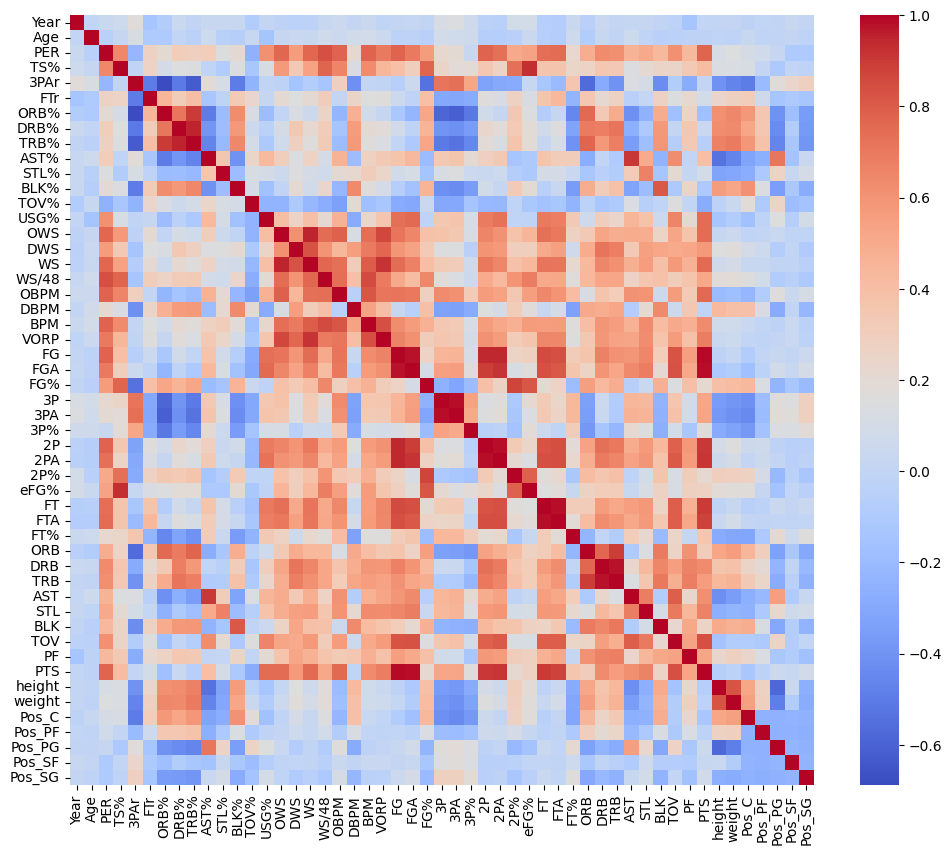

In [51]:
## Assess which variables are correlated to eachother
corr = stats.corr()
plt.figure(figsize = (12,10))
sns.heatmap(corr, annot = False, cmap = 'coolwarm')
plt.show()

In [52]:
# This is the metric we are kind of aiming to mimic and improve upon, so we want to see what correlates
print(corr['VORP'].sort_values(ascending=False))

VORP      1.000000
WS        0.915759
OWS       0.865592
BPM       0.837909
DWS       0.768324
OBPM      0.716160
PER       0.702362
WS/48     0.695632
PTS       0.684404
FG        0.664315
FT        0.652440
FTA       0.650224
STL       0.624463
FGA       0.612161
2P        0.608637
DRB       0.586739
TOV       0.565998
2PA       0.564794
TRB       0.537204
AST       0.528331
TS%       0.442256
DBPM      0.401519
PF        0.382904
BLK       0.372261
eFG%      0.361834
USG%      0.356863
3P        0.353874
ORB       0.344616
3PA       0.340030
AST%      0.336845
2P%       0.318383
FG%       0.303497
STL%      0.245573
DRB%      0.181061
FTr       0.166997
FT%       0.159910
TRB%      0.129404
BLK%      0.096964
3P%       0.089848
weight    0.060017
Age       0.043910
height    0.039498
Pos_SF    0.036716
ORB%      0.017880
Pos_PG    0.009139
Pos_C    -0.000514
3PAr     -0.004449
Pos_PF   -0.012099
Year     -0.014291
Pos_SG   -0.031778
TOV%     -0.126670
Name: VORP, dtype: float64


In [53]:
### Some of the variables are not going to hae values becuase the prcentage is undefined so we set these to a 0% for consistency purposes

stats['3P%'] = stats['3P%'].fillna(0)
stats['2P%'] = stats['2P%'].fillna(0)
stats['FT%'] = stats['FT%'].fillna(0)

stats.info()

<class 'pandas.DataFrame'>
Index: 5269 entries, 17662 to 24690
Data columns (total 51 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Year    5269 non-null   float64
 1   Age     5269 non-null   float64
 2   PER     5269 non-null   float64
 3   TS%     5269 non-null   float64
 4   3PAr    5269 non-null   float64
 5   FTr     5269 non-null   float64
 6   ORB%    5269 non-null   float64
 7   DRB%    5269 non-null   float64
 8   TRB%    5269 non-null   float64
 9   AST%    5269 non-null   float64
 10  STL%    5269 non-null   float64
 11  BLK%    5269 non-null   float64
 12  TOV%    5269 non-null   float64
 13  USG%    5269 non-null   float64
 14  OWS     5269 non-null   float64
 15  DWS     5269 non-null   float64
 16  WS      5269 non-null   float64
 17  WS/48   5269 non-null   float64
 18  OBPM    5269 non-null   float64
 19  DBPM    5269 non-null   float64
 20  BPM     5269 non-null   float64
 21  VORP    5269 non-null   float64
 22  FG      526

In [54]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import silhouette_score
from sklearn.metrics import silhouette_samples

## These stats are metrics of overall player perfomance so we want to eliminate them so we can capture player performance and style not overall talent.
## Eliminating some counting stats so we don't cluster players based on performance and jsut play styles
X = stats.drop(columns = ["VORP", "BPM", "WS", "WS/48", "OWS", "DWS", "OBPM", "DBPM", "PER", "PTS", "FG", "FT", "FTA", "2P", "2PA", "3P", "3PA", "Year", "Age"])

y = stats['VORP']

#Because stats like points are a much higher number than steals, we want this to be neutralized so scale the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X)


Components needed for 90% variance: 13
Components needed for 95% variance: 16
Components needed for 99% variance: 22


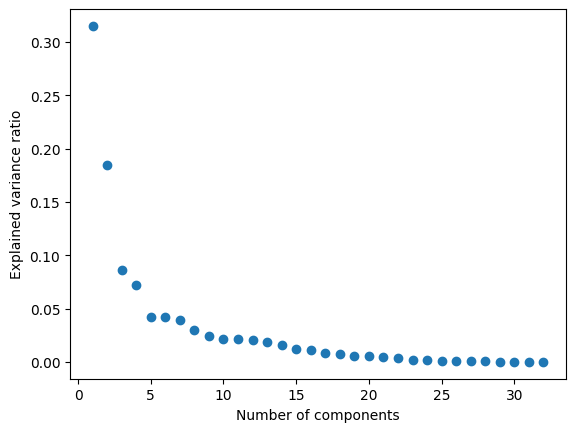

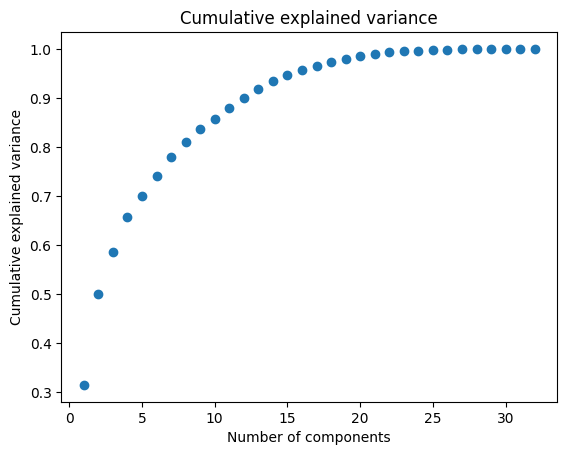

In [55]:
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Fit PCA on the scaled data
pca = PCA()
pca.fit(X_train)

# Explained variance ratio
evr = pca.explained_variance_ratio_

# plot # of components vs the variance ratio
# plot evr from x=1
plt.plot(range(1, len(evr) + 1),evr,'o')
# x axis
plt.xlabel('Number of components')
# y axis
plt.ylabel('Explained variance ratio')

# Calculate cumulative explained variance
cev = np.cumsum(evr)


# Plot cumulative explained variance
plt.figure()
plt.plot(range(1, len(cev) + 1),cev,'o')
plt.title('Cumulative explained variance')
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')

# Find number of components needed for each threshold

thresholds = [0.90, 0.95, 0.99]

for t in thresholds:
    n_components = np.argmax(cev >= t) + 1  # +1 because index starts at 0
    print(f"Components needed for {int(t*100)}% variance: {n_components}")


In [56]:
pca = PCA(n_components=0.9)
X_pca = pca.fit_transform(X_train)

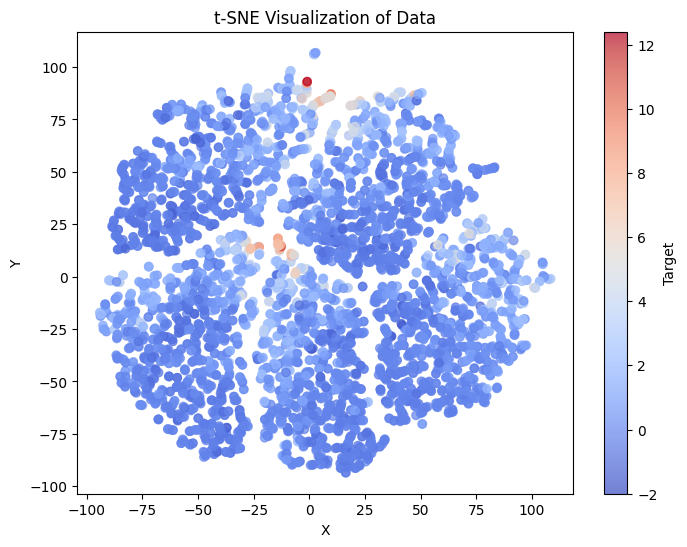

In [57]:
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE


tsne = TSNE(random_state=42, perplexity=5)

X_tsne = tsne.fit_transform(X_pca)


plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='coolwarm', alpha=0.7)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("t-SNE Visualization of Data")
plt.colorbar(scatter, label="Target")
plt.show()

We can see that mini clusters do form in the data that kind of look like church pews. We also see that the values get brighter as we move to the riight indicating that there are certainly patterns and clusters in the data.

Best k: 2
Best silhouette score: 0.2529918347394223


array([3, 8, 0, ..., 6, 5, 6], shape=(5269,), dtype=int32)

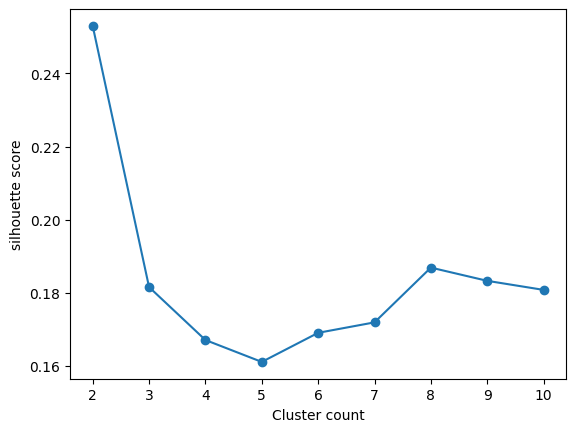

In [58]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

## Use the silhouette score method to determine the best number of clusters to use for our clustering methods
silhouettes = []
k_values = range(2,11)


## Run the kmeans clustering function for all the different k values and then determine which k value we are going to use
for k in range(2,11):
  kmeans = KMeans(n_clusters=k, random_state = 42, init = 'k-means++', n_init = "auto")
  cluster_labels = kmeans.fit_predict(X_pca)
  score = silhouette_score(X_pca, cluster_labels)
  silhouettes.append(score)


## Plot and find out the k values with their respective silhouette scores
best_k = k_values[np.argmax(silhouettes)]
best_score = max(silhouettes)

print("Best k:", best_k)
print("Best silhouette score:", best_score)


plt.plot(k_values, silhouettes, marker='o')
plt.xlabel('Cluster count')
plt.ylabel('silhouette score')
plt.show

cluster_labels

We are going to be using the k value of 8 because even though it has a worse silhouette score than clusters 2 and 3, we want to be able to cluster the players into better groups than good and bad players. This will align with the amount of basketball positions and archetypes that we had in mind going into the project so we are pleased with this view.

In [59]:
best_k = 8

print("Silhouette score for k = 8", silhouette_score(X_pca, KMeans(n_clusters=best_k, random_state=42, init='k-means++', n_init="auto").fit_predict(X_pca)))

Silhouette score for k = 8 0.1869161271626459


In [60]:
# Run our kmeans baseline with the best k clusters and give the clusters to the entirety of the data

kmeans = KMeans(n_clusters=best_k, random_state = 0, n_init = "auto").fit(X_pca)
y = kmeans.predict(X_pca)
clusters = kmeans.labels_

# Find out what the centers are for the individual clusters in our data set
original_centers = pca.inverse_transform(kmeans.cluster_centers_)
centers = pd.DataFrame(
    original_centers,
    columns=X.columns,
    index=[f"Cluster {i}" for i in range(best_k)]
)

In [61]:
## find a way to value the clusters in another manner and interpret the clusters in a manner that isn't silhouette score
from sklearn.metrics import davies_bouldin_score

davies_score = davies_bouldin_score(X_pca, clusters)
print("Davies-Bouldin Score:", davies_score)


Davies-Bouldin Score: 1.6227100472651412


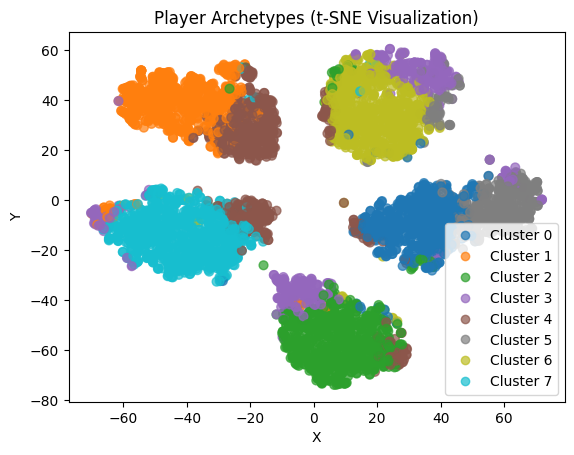

In [62]:
## visualize our tsne so we can see the clusters in action adn determine the patterns

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_pca)


## Scatter plot of the t-SNE results with clusters colored differently
scatter = plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=clusters,
    cmap='tab10',
    alpha=0.7,
    s=40
)

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Player Archetypes (t-SNE Visualization)")
plt.legend(handles=scatter.legend_elements()[0], labels=[f"Cluster {i}" for i in range(best_k)])
plt.show()

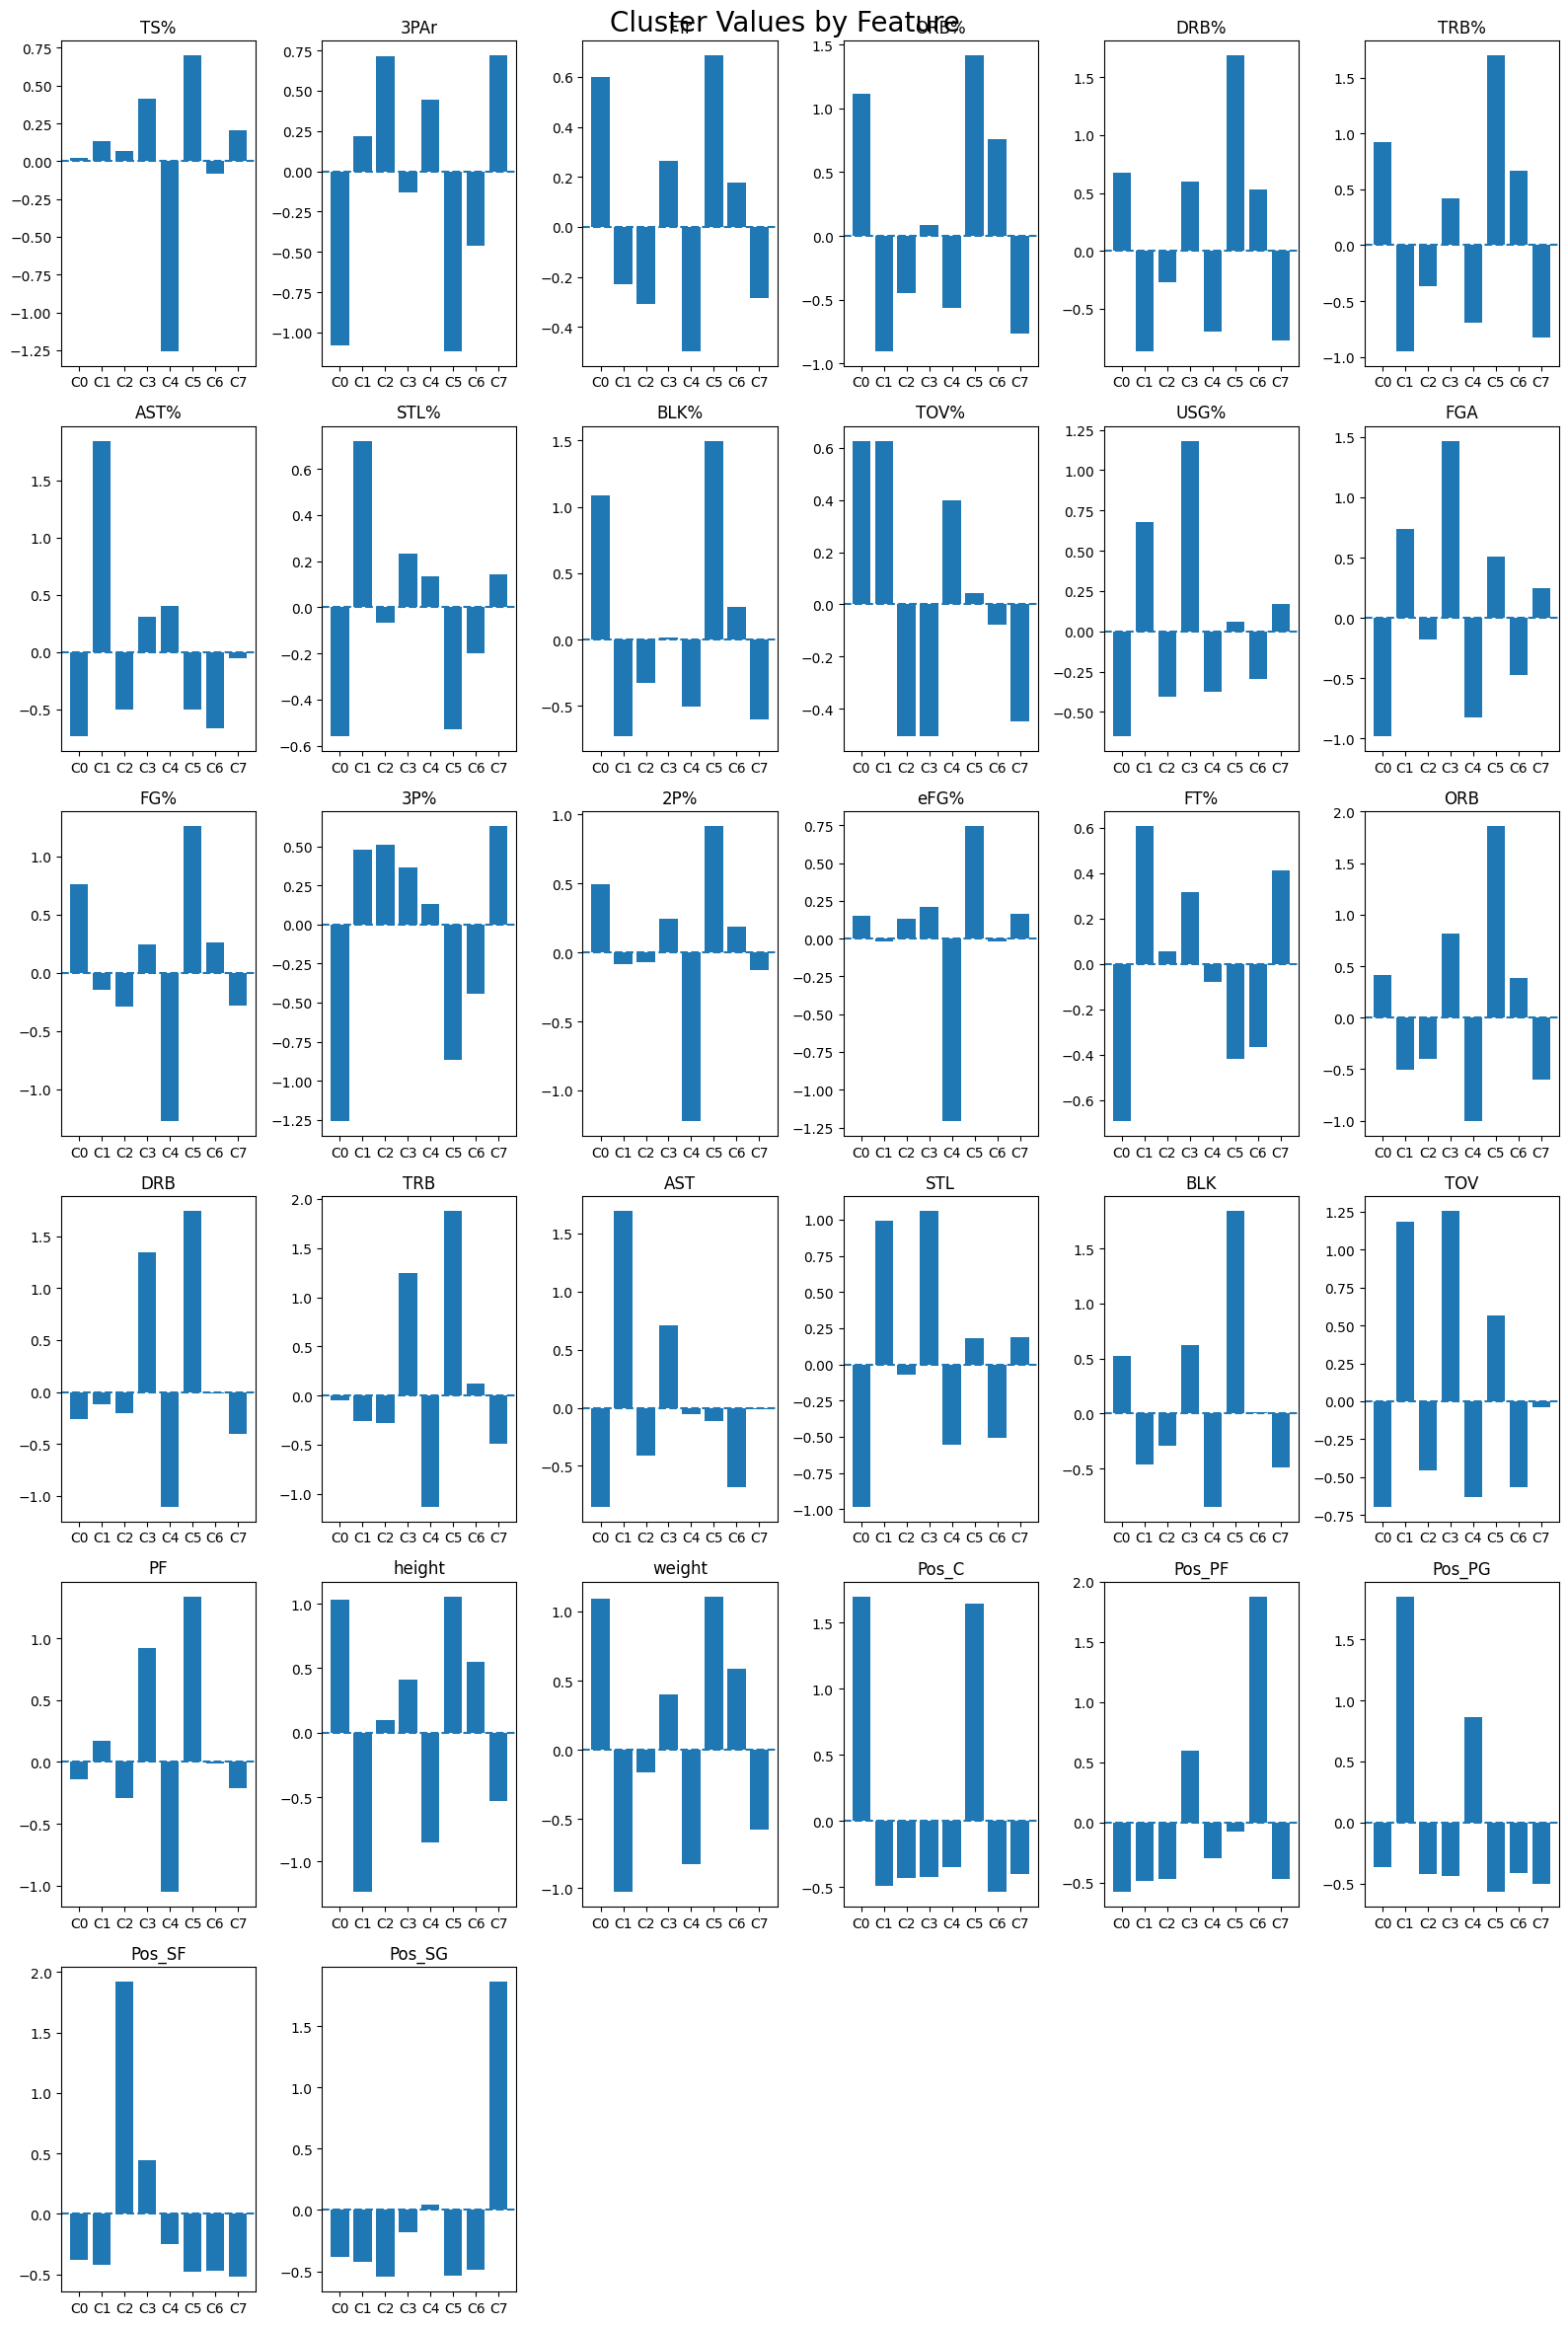

In [63]:
import matplotlib.pyplot as plt
import math

## Plot out all of the different clusters so we can identify which features they value the most.
features = centers.columns
n_features = len(features)

ncols = 6
nrows = math.ceil(n_features / ncols)


## Plot the individual columns one at a time so we have this clear view
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4*nrows))
axes = axes.flatten()

for i, feature in enumerate(features):
    ax = axes[i]

    values = centers[feature]

    ax.bar(range(len(values)), values)
    ax.set_title(feature)
    ax.set_xticks(range(len(values)))
    ax.set_xticklabels([f"C{j}" for j in range(len(values))])
    ax.axhline(0, linestyle='--')

# remove extra plots
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.suptitle("Cluster Values by Feature", fontsize=20)
plt.tight_layout()
plt.show()

In [ ]:
# Printing the centers to digest for the gemini model to interpret and give us insights on the clusters we identified
print(centers.to_string())

                TS%      3PAr       FTr      ORB%      DRB%      TRB%      AST%      STL%      BLK%      TOV%      USG%       FGA       FG%       3P%       2P%      eFG%       FT%       ORB       DRB       TRB       AST       STL       BLK       TOV        PF    height    weight     Pos_C    Pos_PF    Pos_PG    Pos_SF    Pos_SG
Cluster 0  0.022045 -1.078384  0.601472  1.116502  0.674590  0.922069 -0.733272 -0.558210  1.086617  0.624286 -0.650886 -0.980339  0.760273 -1.260925  0.491780  0.153680 -0.693307  0.414491 -0.257328 -0.045186 -0.849344 -0.982813  0.525516 -0.694042 -0.140868  1.029959  1.091721  1.699487 -0.574158 -0.368807 -0.379411 -0.382048
Cluster 1  0.135984  0.217131 -0.229962 -0.900878 -0.864641 -0.946371  1.843409  0.722251 -0.726669  0.626728  0.677611  0.733978 -0.148817  0.483137 -0.082636 -0.020151  0.608139 -0.508196 -0.118403 -0.256078  1.691832  0.992404 -0.460531  1.185529  0.172051 -1.234114 -1.026473 -0.492581 -0.486458  1.852639 -0.421734 -0.426661
Cluster 2 

FOUND USING AI GEMINI ON GOOGLE COLAB, UNABLE TO GET AN API KEY SO RAN AND THE RESULTS ARE PASTED

Cluster 0 - Rim protectors (Mid)
cluster 1 - Playmakers (Good)
cluster 2 - 3 and D Wings (Good)
Cluster 3 - Offensive Engines (Good)
cluster 4 - Inefficient Scorers (Bad)
cluster 5 - Paint Beasts (Good)
cluster 6 - Physical Forwards (Mid)
cluster 7 - 3 point sharp shooters (no Defense) (Good)

In [ ]:
## RESET THE DATA back to what it was before so we can regress using all of the individual statistics

stats = pd.read_csv('Seasons_Stats.csv')
players = pd.read_csv('Players.csv')

stats = pd.merge(stats,players, left_on = 'Player', right_on = 'Player')

#These are currently counting stats - we want them to be on a per game basis so they can be adjusted for guys who didn't play as many games
per_game_stats = ['PTS', 'AST', 'TRB', 'STL', 'BLK', 'FGA', 'FG', 'FTA', 'FT', '3PA', '3P', '2P', '2PA','ORB','DRB','TOV','PF','MP']

#Only use the modern nba and cut out the 2017 season so we can use it for test
stats_test = stats[stats['Year'] == 2017]
stats = stats[stats['Year'] >= 2006]

#Make sure everybody in the data has played enough games to the point where they aren't a major outlier for one great game out of about 3 played.
stats_test = stats_test[stats_test['G'] > 15]
stats = stats[stats['G'] > 15]

stats = stats[stats['MP'] > 10]
stats_test = stats_test[stats_test['MP'] > 10]


#Per game stats are more important for the regression so we want to convert these back to per game stats
for stat in per_game_stats:
    stats[stat] = stats[stat] / stats['G']

for stat in per_game_stats:
    stats_test[stat] = stats_test[stat] / stats_test['G']

stats = stats[stats['Tm'] != 'TOT']


pd.set_option('display.max_columns', None)
stats.head()

,Unnamed: 0_x,Year,Player,Pos,Age,Tm,G,GS,MP,PER,TS%,3PAr,FTr,ORB%,DRB%,TRB%,AST%,STL%,BLK%,TOV%,USG%,blanl,OWS,DWS,WS,WS/48,blank2,OBPM,DBPM,BPM,VORP,FG,FGA,FG%,3P,3PA,3P%,2P,2PA,2P%,eFG%,FT,FTA,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,Unnamed: 0_y,height,weight,collage,born,birth_city,birth_state
17662,17662,2006.0,Shareef Abdur-Rahim,PF,29.0,SAC,72.0,30.0,27.236111,17.2,0.588,0.035,0.440,6.4,14.8,10.6,13.2,1.3,1.6,12.5,20.1,NaN,4.0,2.2,6.2,0.152,NaN,0.4,0.4,0.9,1.4,4.611111,8.777778,0.525,0.069444,0.305556,0.227,4.541667,8.472222,0.536,0.529,3.027778,3.861111,0.784,1.472222,3.486111,4.958333,2.069444,0.666667,0.583333,1.500000,3.152778,12.319444,2449,206.0,102.0,University of California,1976.0,Marietta,Georgia
17664,17664,2006.0,Malik Allen,PF,27.0,CHI,54.0,20.0,12.981481,11.5,0.504,0.004,0.154,7.2,15.7,11.5,4.9,1.0,1.8,11.4,19.2,NaN,0.0,1.0,1.0,0.068,NaN,-3.9,0.0,-3.9,-0.3,2.240741,4.574074,0.490,0.018519,0.018519,1.000,2.222222,4.555556,0.488,0.492,0.425926,0.703704,0.605,0.814815,1.777778,2.592593,0.370370,0.259259,0.296296,0.629630,1.703704,4.925926,2776,208.0,115.0,Villanova University,1978.0,Willingboro,New Jersey
17665,17665,2006.0,Ray Allen,SG,30.0,SEA,78.0,78.0,38.743590,22.2,0.590,0.435,0.239,2.8,10.6,6.6,17.2,1.8,0.4,10.2,27.4,NaN,9.8,-0.3,9.5,0.150,NaN,6.7,-3.1,3.6,4.2,8.730769,19.230769,0.454,3.448718,8.371795,0.412,5.282051,10.858974,0.486,0.544,4.153846,4.602564,0.903,0.910256,3.346154,4.256410,3.666667,1.346154,0.205128,2.410256,1.935897,25.064103,2450,203.0,99.0,Florida State University,1965.0,Milton,Florida
17666,17666,2006.0,Tony Allen,PG,24.0,BOS,51.0,9.0,19.176471,12.9,0.554,0.124,0.489,4.1,9.6,6.9,11.2,2.7,1.4,16.8,18.8,NaN,0.6,1.0,1.7,0.082,NaN,-1.6,0.2,-1.4,0.2,2.529412,5.372549,0.471,0.215686,0.666667,0.324,2.313725,4.705882,0.492,0.491,1.960784,2.627451,0.746,0.627451,1.549020,2.176471,1.313725,1.000000,0.352941,1.313725,2.470588,7.235294,2974,193.0,96.0,Oklahoma State University,1982.0,Chicago,Illinois
17667,17667,2006.0,Rafer Alston,PG,29.0,HOU,63.0,63.0,38.587302,12.6,0.475,0.423,0.194,1.8,10.4,6.1,30.8,2.3,0.5,16.4,18.8,NaN,0.2,3.1,3.4,0.067,NaN,0.1,0.7,0.8,1.7,4.444444,11.714286,0.379,1.619048,4.952381,0.327,2.825397,6.761905,0.418,0.449,1.571429,2.269841,0.692,0.571429,3.476190,4.047619,6.746032,1.603175,0.238095,2.492063,3.079365,12.079365,2648,188.0,77.0,"California State University, Fresno",1976.0,New York,New York


In [ ]:
stats = stats.drop(columns = ['Unnamed: 0_x', 'Unnamed: 0_y', 'collage', 'born', 'birth_city', 'birth_state', 'blanl','blank2', 'Tm', 'Age', 'G', 'GS', 'MP', 'Pos', 'height', 'weight'])

## Once again these percentages are going to be 0 if undefined
stats['3P%'] = stats['3P%'].fillna(0)
stats['2P%'] = stats['2P%'].fillna(0)
stats['FT%'] = stats['FT%'].fillna(0)

stats.info()

<class 'pandas.DataFrame'>
Index: 5269 entries, 17662 to 24690
Data columns (total 44 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Year    5269 non-null   float64
 1   Player  5269 non-null   str    
 2   PER     5269 non-null   float64
 3   TS%     5269 non-null   float64
 4   3PAr    5269 non-null   float64
 5   FTr     5269 non-null   float64
 6   ORB%    5269 non-null   float64
 7   DRB%    5269 non-null   float64
 8   TRB%    5269 non-null   float64
 9   AST%    5269 non-null   float64
 10  STL%    5269 non-null   float64
 11  BLK%    5269 non-null   float64
 12  TOV%    5269 non-null   float64
 13  USG%    5269 non-null   float64
 14  OWS     5269 non-null   float64
 15  DWS     5269 non-null   float64
 16  WS      5269 non-null   float64
 17  WS/48   5269 non-null   float64
 18  OBPM    5269 non-null   float64
 19  DBPM    5269 non-null   float64
 20  BPM     5269 non-null   float64
 21  VORP    5269 non-null   float64
 22  FG      526

In [67]:
## Set up our data for the linear regression where we are trying to create a statistic such as VORP
stats["Cluster"] = clusters
stats = pd.get_dummies(stats, columns = ['Cluster'])
X = stats.drop(columns = ["VORP", "OBPM", "DBPM", "BPM", "WS", "WS/48", "Player", "Year"])
y = stats['VORP']
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 42)

#Because stats like points are a much higher number than steals, we want this to be neutralized so scale the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

from sklearn.linear_model import LinearRegression

linear = LinearRegression()
linear.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

## Predict the values using our new regression model
y_train_pred = linear.predict(X_train)
y_test_pred = linear.predict(X_test)

## Evaluate the model using R2 and MSE for both the train and test sets
linear_test_r2 = r2_score(y_test, y_test_pred)
linear_test_mse = mean_squared_error(y_test, y_test_pred)
linear_train_r2 = r2_score(y_train, y_train_pred)
linear_train_mse = mean_squared_error(y_train, y_train_pred)

print("Linear Train MSE:", mean_squared_error(y_train, y_train_pred))
print("Linear Test MSE:", mean_squared_error(y_test, y_test_pred))

print("Linear Train R2:", r2_score(y_train, y_train_pred))
print("Linear Test R2:", r2_score(y_test, y_test_pred))

Linear Train MSE: 0.1639062640506548
Linear Test MSE: 0.16408625176687464
Linear Train R2: 0.9143503815846508
Linear Test R2: 0.9120635090421991


In [ ]:
## Determine the most important features of the linear regression model
coeffs = pd.Series(linear.coef_, index=X.columns)
print(coeffs.sort_values(ascending=False).head(10))

OWS     0.868755
TRB%    0.689007
DWS     0.381541
AST%    0.319760
STL     0.319073
eFG%    0.307938
2P      0.294257
BLK     0.277015
FG      0.255714
FT      0.252800
dtype: float64


very interesting that our best coefficient by far is OWS and DWS is pretty far behind that number. Our baseline is pretty close to VORP, but this isn't what we are trying to replicate fully at the end of the day. Therefore we don't really care about the results similarity. We have a baseline regression that can predict a players value

In [70]:
#Setup the features the same as the model
X_data = stats.drop(columns=["VORP", "OBPM", "DBPM", "BPM", "WS", "WS/48", "Player", "Year"])

# Transform the data so we can predict the WAR with our player values
X_data_scaled = scaler.transform(X_data)

In [71]:
# Create the leaderboard so we have the important counting stats and the VORP plus our new prediciton
leaderboard_predictor = stats
leaderboard_predictor["WAR"] = linear.predict(X_data_scaled)

leaderboard = leaderboard_predictor[["Year", "Player", "PTS", "AST", "TRB", "VORP", "WAR", "BPM", "STL","BLK","3P", "USG%", "PER"]]
leaderboard = leaderboard.sort_values(by="WAR", ascending=False)
leaderboard.head()

,Year,Player,PTS,AST,TRB,VORP,WAR,BPM,STL,BLK,3P,USG%,PER
19611,2009.0,LeBron James,28.444444,7.246914,7.567901,11.6,9.287561,13.0,1.691358,1.148148,1.629630,33.8,31.7
21933,2013.0,LeBron James,26.789474,7.250000,8.026316,9.8,9.103786,11.6,1.697368,0.881579,1.355263,30.2,31.6
20207,2010.0,LeBron James,29.710526,8.565789,7.289474,10.9,8.970468,12.5,1.644737,1.013158,1.697368,33.5,31.1
19752,2009.0,Chris Paul,22.833333,11.038462,5.538462,10.0,8.487284,11.2,2.769231,0.128205,0.820513,27.5,30.0
21827,2013.0,Kevin Durant,28.148148,4.617284,7.901235,7.6,8.416676,7.7,1.432099,1.296296,1.716049,29.8,28.3


In [72]:
leaderboard[leaderboard["Year"] == 2017.0].head(20)

,Year,Player,PTS,AST,TRB,VORP,WAR,BPM,STL,BLK,3P,USG%,PER
24306,2017.0,James Harden,29.086420,11.185185,8.135802,9.0,7.495351,10.1,1.481481,0.456790,3.234568,34.2,27.3
24654,2017.0,Russell Westbrook,31.580247,10.370370,10.666667,12.4,6.896538,15.6,1.641975,0.382716,2.469136,41.7,30.6
24365,2017.0,LeBron James,26.405405,8.729730,8.648649,7.3,6.413587,8.4,1.243243,0.594595,1.675676,30.0,27.0
24175,2017.0,Jimmy Butler,23.894737,5.486842,6.184211,6.3,6.273786,6.9,1.881579,0.421053,1.197368,26.5,25.1
24115,2017.0,Giannis Antetokounmpo,22.900000,5.425000,8.750000,6.9,6.153418,7.6,1.637500,1.887500,0.612500,28.3,26.1
24414,2017.0,Kawhi Leonard,25.513514,3.513514,5.810811,6.2,6.121527,7.9,1.783784,0.743243,1.986486,31.1,27.5
24239,2017.0,Kevin Durant,25.080645,4.838710,8.274194,5.2,5.847908,8.0,1.064516,1.596774,1.887097,27.8,27.6
24216,2017.0,Stephen Curry,25.303797,6.620253,4.468354,6.2,5.699579,7.3,1.810127,0.215190,4.101266,30.1,24.6
24285,2017.0,Rudy Gobert,14.037037,1.197531,12.777778,5.4,5.551002,5.8,0.604938,2.641975,0.000000,16.7,23.3
24522,2017.0,Chris Paul,18.098361,9.229508,4.983607,5.2,5.115463,8.7,1.934426,0.131148,2.032787,24.4,26.2


In [ ]:
## Save the data with the clusters and linear regression war for other modeling
stats.to_csv("nba_model_ready.csv", index=False)

In [ ]:
## Identify the individual cluster for each player for welch test
cluster_cols = [col for col in stats.columns if "Cluster_" in col]

stats["Cluster_Label"] = (stats[cluster_cols].idxmax(axis=1).str.replace("Cluster_", "").astype(int))

In [84]:
## Perform a welch test to determine whether the clusters we identified are statistically significant in terms of their VORP values. This is a test that is used when the variances of the groups are not equal, which is likely the case here given the nature of the data and the clustering method used.
import pingouin as pg
welch = pg.welch_anova(dv='VORP', between='Cluster_Label', data=stats)

print(welch)

          Source  ddof1        ddof2           F  p_unc       np2
0  Cluster_Label      7  2065.259429  388.630088    0.0  0.330181
